In [ ]:
# librerias 

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

In [289]:
# cargar data 
BASE_DIR = Path().resolve().parent

# datasets por año
data2009 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2009.csv", low_memory=False)
data2010 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2010.csv", low_memory=False)
data2011 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2011.csv", low_memory=False)
data2012 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2012.csv", low_memory=False)
data2013 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2013.csv", low_memory=False)
data2014 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2014.csv", low_memory=False)
data2015 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2015.csv", low_memory=False)
data2016 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2016.csv", low_memory=False)
data2017 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2017.csv", low_memory=False)
data2018 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2018.csv", low_memory=False)
data2019 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2019.csv", low_memory=False)
data2020 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2020.csv", low_memory=False)
data2021 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2021.csv", low_memory=False)
data2022 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2022.csv", low_memory=False)

# diccionarios
diccionario_defun = pd.read_csv(BASE_DIR / "data/processed/diccionario_defunciones.csv", encoding="latin1", sep=";" )
diccionario_cie = pd.read_csv(BASE_DIR / "data/processed/diccionario_codigos_CIE-10.csv",   encoding="latin1", sep=";",)
diccionario_cie_cat = pd.read_csv(BASE_DIR / "data/processed/diccionario_categorías_subcategorías_CIE-10.csv",   encoding="latin1", sep=";")




### Diccionarios

In [290]:
diccionario_defun.head(5)

,Variable,Código,Etiqueta
0,Depreg,1,Guatemala
1,Depreg,2,El Progreso
2,Depreg,3,Sacatepéquez
3,Depreg,4,Chimaltenango
4,Depreg,5,Escuintla


In [291]:
# cuántos tipos de variables hay en el de defunción
diccionario_defun["Código"].nunique()

889

In [292]:
diccionario_cie.head(2)


,Causa de defuncion,Codigos CIE-10,Codigos CIE-10.1
0,Asist,1,Médica
1,Asist,2,Paramédica


In [293]:
diccionario_cie["Codigos CIE-10"].nunique()

9

In [294]:
diccionario_cie_cat.head(2)


,CAUSA,DESCRIP
0,A00,Cólera
1,A000,"Cólera debido a Vibrio cholerae 01, biotipo ch..."


In [295]:
diccionario_cie_cat["CAUSA"].nunique()

14238

### Data

In [296]:
# los registros totales de la data
data_all = pd.concat([ data2009.assign(anio=2009), data2010.assign(anio=2010), data2011.assign(anio=2011), data2012.assign(anio=2012), data2013.assign(anio=2013), data2014.assign(anio=2014), data2015.assign(anio=2015), data2016.assign(anio=2016), data2017.assign(anio=2017), data2018.assign(anio=2018), data2019.assign(anio=2019), data2020.assign(anio=2020), data2021.assign(anio=2021), data2022.assign(anio=2022), ], ignore_index=True)
data_all.shape

(1167602, 36)

In [297]:
# variables de la data
list(data_all.columns)


['Depreg',
 'Mupreg',
 'Mesreg',
 'Añoreg',
 'Depocu',
 'Mupocu',
 'Areag',
 'Sexo',
 'Diaocu',
 'Mesocu',
 'Añoocu',
 'Edadif',
 'Perdif',
 'Getdif',
 'Ecidif',
 'Ocudif',
 'Dnadif',
 'Mnadif',
 'Nacdif',
 'Dredif',
 'Mredif',
 'Caudef',
 'Asist',
 'Ocur',
 'Cerdef',
 'anio',
 'mupreg',
 'mupocu',
 'añoocu',
 'Escodif',
 'mnadif',
 'Pnadif',
 'Predif',
 'Puedif',
 'Ciuodif',
 'caudef.descrip']

In [298]:
print(data_all.columns)

Index(['Depreg', 'Mupreg', 'Mesreg', 'Añoreg', 'Depocu', 'Mupocu', 'Areag',
       'Sexo', 'Diaocu', 'Mesocu', 'Añoocu', 'Edadif', 'Perdif', 'Getdif',
       'Ecidif', 'Ocudif', 'Dnadif', 'Mnadif', 'Nacdif', 'Dredif', 'Mredif',
       'Caudef', 'Asist', 'Ocur', 'Cerdef', 'anio', 'mupreg', 'mupocu',
       'añoocu', 'Escodif', 'mnadif', 'Pnadif', 'Predif', 'Puedif', 'Ciuodif',
       'caudef.descrip'],
      dtype='object')


In [299]:
# los registros que hay por año
data_all["anio"].value_counts().sort_index()


anio
2009     71707
2010     72748
2011     72354
2012     72657
2013     76639
2014     77807
2015     80876
2016     82565
2017     81726
2018     83071
2019     85600
2020     96001
2021    118465
2022     95386
Name: count, dtype: int64

##### Resumen de la data 

In [300]:

data_all.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Depreg,1167602.0,NaN,NaN,NaN,8.632042,6.690105,1.0,1.0,9.0,14.0,22.0
Mupreg,1022500.0,NaN,NaN,NaN,869.559309,669.798178,101.0,103.0,901.0,1406.0,2217.0
Mesreg,1167602.0,NaN,NaN,NaN,6.503207,3.430613,1.0,4.0,7.0,9.0,12.0
Añoreg,1167602.0,NaN,NaN,NaN,1893.195257,481.982417,9.0,2013.0,2016.0,2020.0,2023.0
Depocu,1167602.0,NaN,NaN,NaN,8.602418,6.66619,1.0,1.0,9.0,14.0,22.0
Mupocu,1022500.0,NaN,NaN,NaN,866.889631,666.767946,101.0,113.0,901.0,1406.0,2217.0
Areag,689079.0,NaN,NaN,NaN,1.596917,1.160354,1.0,1.0,1.0,2.0,9.0
Sexo,1167602.0,NaN,NaN,NaN,1.436969,0.496011,1.0,1.0,1.0,2.0,2.0
Diaocu,1167602.0,NaN,NaN,NaN,15.672263,8.814839,1.0,8.0,16.0,23.0,31.0
Mesocu,1167602.0,NaN,NaN,NaN,6.561291,3.424092,1.0,4.0,7.0,9.0,12.0


In [301]:
data_all.describe()

,Depreg,Mupreg,Mesreg,Añoreg,Depocu,Mupocu,Areag,Sexo,Diaocu,Mesocu,...,Cerdef,anio,mupreg,mupocu,añoocu,Escodif,mnadif,Pnadif,Predif,Puedif
count,1.167602e+06,1.022500e+06,1.167602e+06,1.167602e+06,1.167602e+06,1.022500e+06,689079.000000,1.167602e+06,1.167602e+06,1.167602e+06,...,1.167602e+06,1.167602e+06,145102.000000,145102.000000,145102.000000,1.095895e+06,72748.000000,950793.000000,950793.000000,878136.000000
mean,8.632042e+00,8.695593e+02,6.503207e+00,1.893195e+03,8.602418e+00,8.668896e+02,1.596917,1.436969e+00,1.567226e+01,6.561291e+00,...,3.983861e+00,2.015997e+03,866.225476,863.574713,2010.498642,2.291988e+00,1125.603797,376.925210,1080.544882,4.078857
std,6.690105e+00,6.697982e+02,3.430613e+00,4.819824e+02,6.666190e+00,6.667679e+02,1.160354,4.960114e-01,8.814839e+00,3.424092e+00,...,3.845096e+00,4.065845e+00,675.762877,673.383045,0.500000,2.254365e+00,1127.835615,735.770567,2603.734900,2.654025
min,1.000000e+00,1.010000e+02,1.000000e+00,9.000000e+00,1.000000e+00,1.010000e+02,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,2.009000e+03,101.000000,101.000000,2010.000000,1.000000e+00,101.000000,10.000000,40.000000,1.000000
25%,1.000000e+00,1.030000e+02,4.000000e+00,2.013000e+03,1.000000e+00,1.130000e+02,1.000000,1.000000e+00,8.000000e+00,4.000000e+00,...,1.000000e+00,2.013000e+03,108.000000,108.000000,2010.000000,1.000000e+00,411.000000,320.000000,320.000000,1.000000
50%,9.000000e+00,9.010000e+02,7.000000e+00,2.016000e+03,9.000000e+00,9.010000e+02,1.000000,1.000000e+00,1.600000e+01,7.000000e+00,...,1.000000e+00,2.016000e+03,901.000000,901.000000,2010.000000,1.000000e+00,1017.000000,320.000000,320.000000,4.000000
75%,1.400000e+01,1.406000e+03,9.000000e+00,2.020000e+03,1.400000e+01,1.406000e+03,2.000000,2.000000e+00,2.300000e+01,9.000000e+00,...,9.000000e+00,2.020000e+03,1406.000000,1406.000000,2011.000000,2.000000e+00,1601.000000,320.000000,320.000000,4.000000
max,2.200000e+01,2.217000e+03,1.200000e+01,2.023000e+03,2.200000e+01,2.217000e+03,9.000000,2.000000e+00,3.100000e+01,1.200000e+01,...,9.000000e+00,2.022000e+03,2217.000000,2217.000000,2011.000000,9.000000e+00,9999.000000,9999.000000,9999.000000,9.000000


##### Defunciones por año

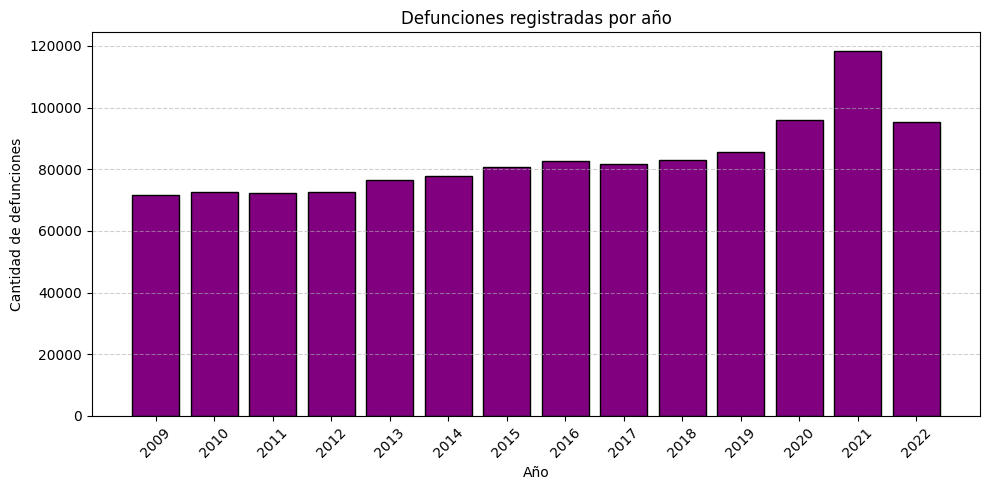

In [302]:
conteo_anual = data_all["anio"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(
    conteo_anual.index.astype(str), 
    conteo_anual.values,
    color="purple",
    edgecolor="black"
)
plt.xlabel("Año")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones registradas por año")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

##### defuncion por edad

In [303]:
edad_limpia = data_all.loc[
    (data_all["Edadif"].notna()) & 
    (data_all["Edadif"] >= 0) & 
    (data_all["Edadif"] < 120),
    "Edadif"
]
edad_limpia.describe()


count    1.158909e+06
mean     5.449856e+01
std      2.786492e+01
min      0.000000e+00
25%      3.300000e+01
50%      6.100000e+01
75%      7.800000e+01
max      1.180000e+02
Name: Edadif, dtype: float64

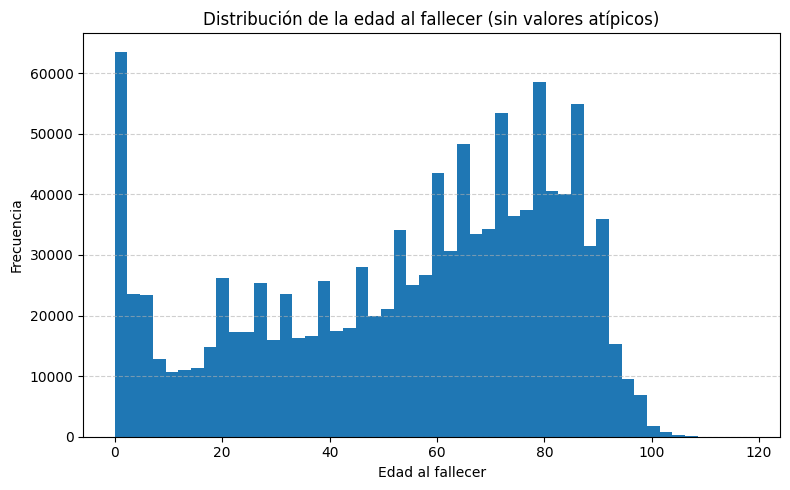

In [304]:
plt.figure(figsize=(8,5))
plt.hist(edad_limpia, bins=50)
plt.xlabel("Edad al fallecer")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad al fallecer (sin valores atípicos)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


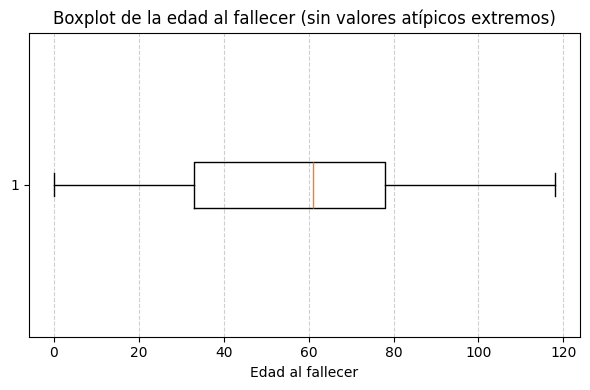

In [305]:
plt.figure(figsize=(6,4))
plt.boxplot(edad_limpia, vert=False)
plt.xlabel("Edad al fallecer")
plt.title("Boxplot de la edad al fallecer (sin valores atípicos extremos)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



##### Defuncion por Genero

In [306]:
mapa_sexo = {
    1: "Hombre",
    2: "Mujer"
}
data_all["Sexo_desc"] = data_all["Sexo"].map(mapa_sexo)


In [307]:
data_all["Sexo_desc"].value_counts()


Sexo_desc
Hombre    657396
Mujer     510206
Name: count, dtype: int64

In [308]:
data_all["Sexo_desc"].value_counts(normalize=True) * 100


Sexo_desc
Hombre    56.30309
Mujer     43.69691
Name: proportion, dtype: float64

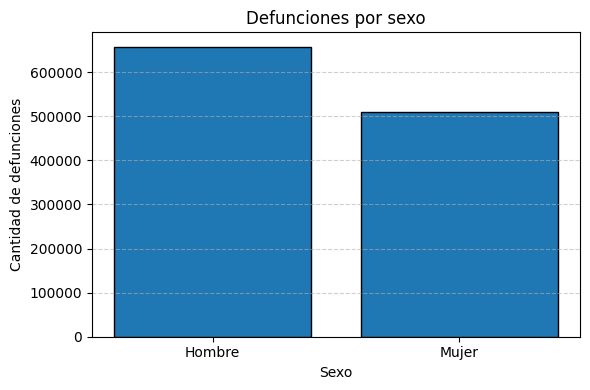

In [309]:
conteo_sexo = data_all["Sexo_desc"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    conteo_sexo.index.astype(str),
    conteo_sexo.values,
    edgecolor="black"
)
plt.xlabel("Sexo")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones por sexo")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


##### Defunciones por area 


In [310]:
mapa_area = {
    1: "Urbana",
    2: "Rural"
}

data_all["Area_desc"] = data_all["Areag"].map(mapa_area)


In [311]:
data_all["Area_desc"].value_counts()


Area_desc
Urbana    373005
Rural     302467
Name: count, dtype: int64

In [312]:
data_all["Area_desc"].value_counts(normalize=True) * 100


Area_desc
Urbana    55.221386
Rural     44.778614
Name: proportion, dtype: float64

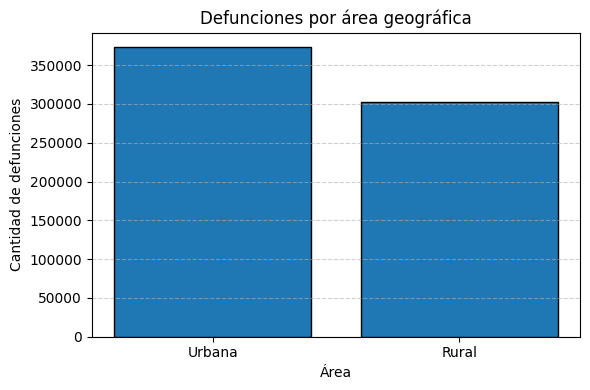

In [313]:
conteo_area = data_all["Area_desc"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    conteo_area.index,
    conteo_area.values,
    edgecolor="black"
)
plt.xlabel("Área")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones por área geográfica")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


##### Defunciones por departamento

In [314]:
diccionario_dep = diccionario_defun[diccionario_defun["Variable"] == "Depreg"]

mapa_dep = dict(
    zip(diccionario_dep["Código"], diccionario_dep["Etiqueta"])
)

data_all["Departamento"] = data_all["Depreg"].map(mapa_dep)


In [315]:
data_all["Departamento"].value_counts().head(10)


Departamento
Guatemala         344116
Quetzaltenango     72051
Alta Verapaz       70046
San Marcos         69249
Huehuetenango      65760
Escuintla          65394
Quiché             58087
Suchitepéquez      43823
Chimaltenango      41080
Jutiapa            35478
Name: count, dtype: int64

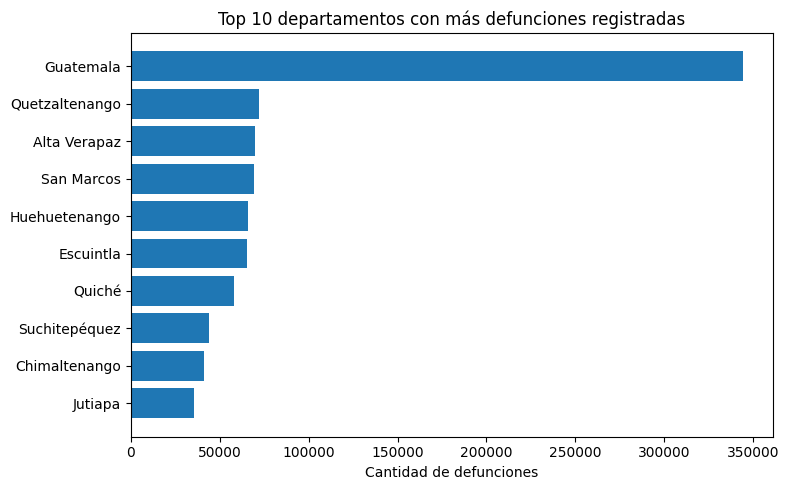

In [316]:
top_dep = data_all["Departamento"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(top_dep.index, top_dep.values)
plt.xlabel("Cantidad de defunciones")
plt.title("Top 10 departamentos con más defunciones registradas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


##### Defuncion por causa

In [317]:
data_all["caudef.descrip"].value_counts().head(10)


caudef.descrip
Neumonía, no especificada                                                                      5251
Infarto agudo del miocardio, sin otra especificación                                           4809
Exposición a factores no especificados, causando otras lesiones y las no especificadas         2703
Diabetes mellitus no especificada, sin mención de complicación                                 2582
Diarrea y gastroenteritis de presunto origen infeccioso                                        2282
Bronconeumonía, no especificada                                                                1984
Muerte sin asistencia                                                                          1906
Otras cirrosis del hígado y las no especificadas                                               1886
Accidente vascular encefálico agudo, no especificado como hemorrágico o isquémico              1836
Agresión con disparo de otras armas de fuego, y las no especificadas, lugar no especi

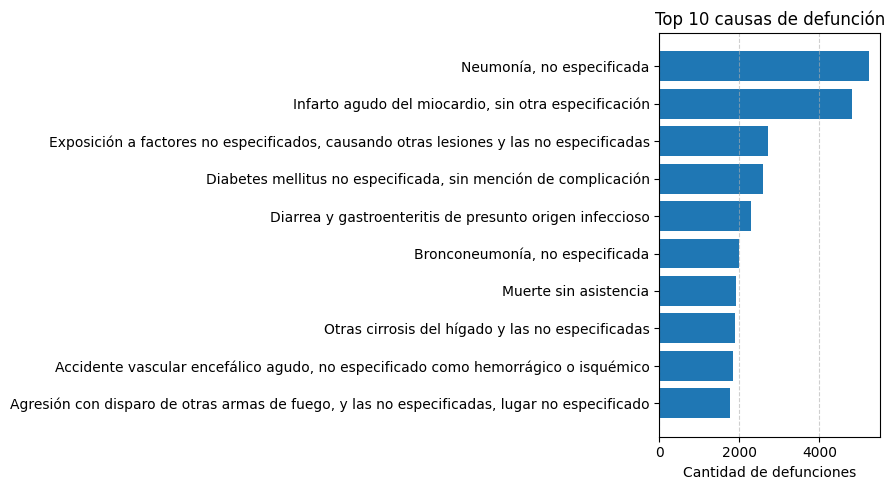

In [318]:
top_causas = data_all["caudef.descrip"].value_counts().head(10)

plt.figure(figsize=(9,5))
plt.barh(top_causas.index, top_causas.values)
plt.xlabel("Cantidad de defunciones")
plt.title("Top 10 causas de defunción")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


#### Datos cruzados 

In [319]:
#edad + sexo
data_cruce = data_all[
    (data_all["Edadif"] >= 0) & (data_all["Edadif"] < 120)
]


<Figure size 600x400 with 0 Axes>

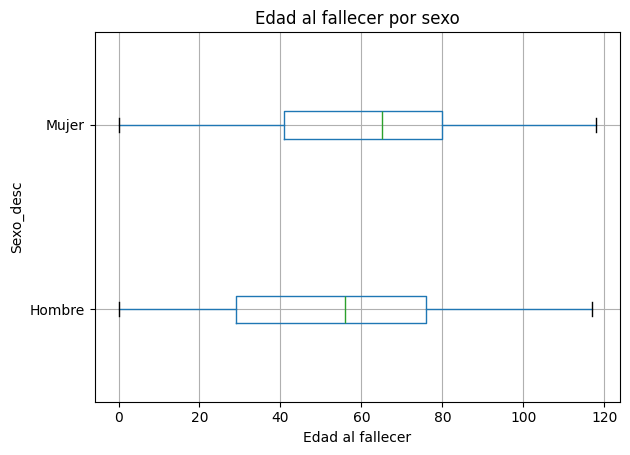

In [320]:
plt.figure(figsize=(6,4))
data_cruce.boxplot(
    column="Edadif",
    by="Sexo_desc",
    vert=False
)
plt.xlabel("Edad al fallecer")
plt.title("Edad al fallecer por sexo")
plt.suptitle("")
plt.tight_layout()
plt.show()


In [321]:
#causa x sexo
top_causas = data_all["caudef.descrip"].value_counts().head(5).index

tabla_causa_sexo = pd.crosstab(
    data_all["Sexo_desc"],
    data_all["caudef.descrip"]
)[top_causas]

tabla_causa_sexo


caudef.descrip,"Neumonía, no especificada","Infarto agudo del miocardio, sin otra especificación","Exposición a factores no especificados, causando otras lesiones y las no especificadas","Diabetes mellitus no especificada, sin mención de complicación",Diarrea y gastroenteritis de presunto origen infeccioso
Sexo_desc,,,,,
Hombre,2750,2579,2210,1044,1206
Mujer,2501,2230,493,1538,1076


C:\Users\belen\AppData\Local\Temp\ipykernel_19252\2405306157.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


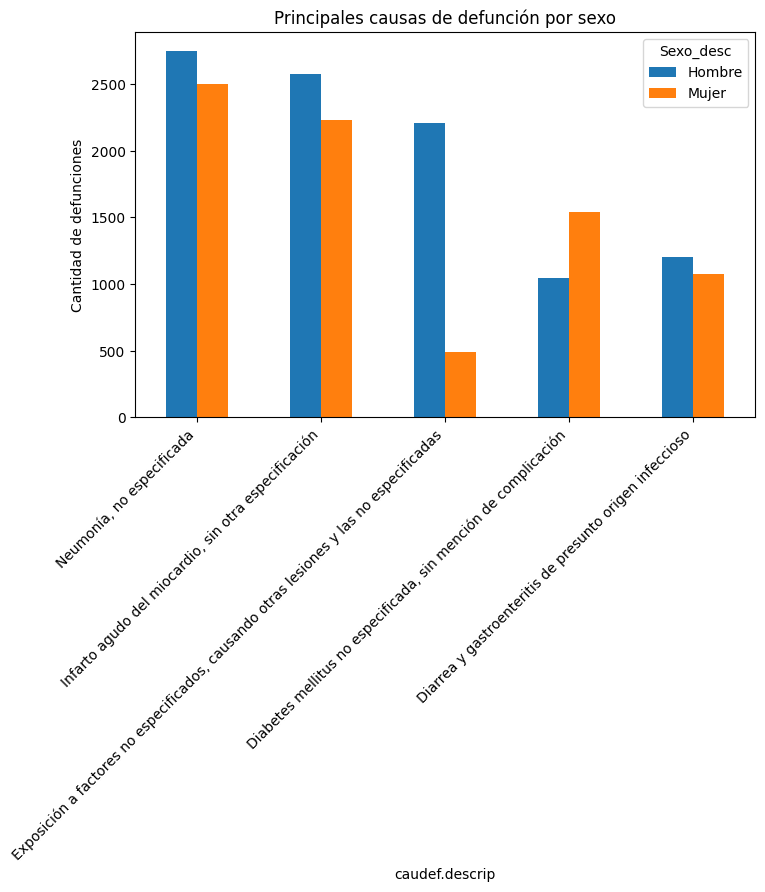

In [322]:
tabla_causa_sexo.T.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Cantidad de defunciones")
plt.title("Principales causas de defunción por sexo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [323]:
#area X causa
tabla_area_causa = pd.crosstab(
    data_all["Area_desc"],
    data_all["caudef.descrip"]
)[top_causas]

tabla_area_causa


caudef.descrip,"Neumonía, no especificada","Infarto agudo del miocardio, sin otra especificación","Exposición a factores no especificados, causando otras lesiones y las no especificadas","Diabetes mellitus no especificada, sin mención de complicación",Diarrea y gastroenteritis de presunto origen infeccioso
Area_desc,,,,,
Rural,3737,2468,741,974,1873
Urbana,1420,2215,1890,1563,374


C:\Users\belen\AppData\Local\Temp\ipykernel_19252\4173242440.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


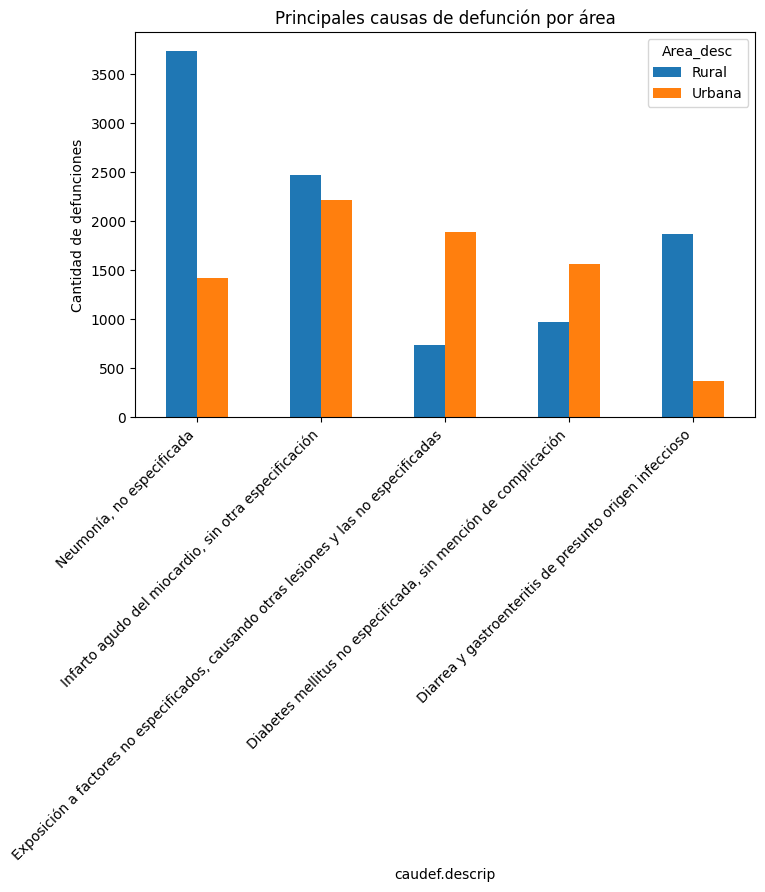

In [324]:
tabla_area_causa.T.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Cantidad de defunciones")
plt.title("Principales causas de defunción por área")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [325]:
#departamento x area 
top_deps = data_all["Departamento"].value_counts().head(5).index


In [326]:
tabla_dep_anio = pd.crosstab(
    data_all["anio"],
    data_all["Departamento"]
)[top_deps]

tabla_dep_anio.head()


Departamento,Guatemala,Quetzaltenango,Alta Verapaz,San Marcos,Huehuetenango
anio,,,,,
2009,21391,4465,4355,4351,3908
2010,22409,4272,4580,4172,4140
2011,21629,4475,4219,4412,4183
2012,21068,4301,4354,4490,4030
2013,22141,4494,4719,4551,4295


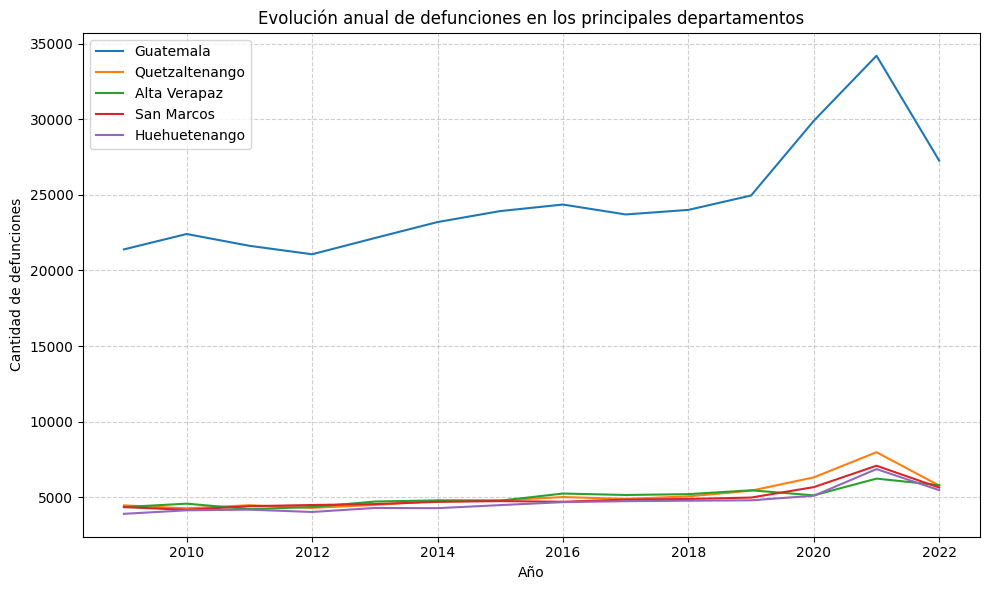

In [327]:
plt.figure(figsize=(10,6))

for dep in top_deps:
    plt.plot(
        tabla_dep_anio.index,
        tabla_dep_anio[dep],
        label=dep
    )

plt.xlabel("Año")
plt.ylabel("Cantidad de defunciones")
plt.title("Evolución anual de defunciones en los principales departamentos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Clustering

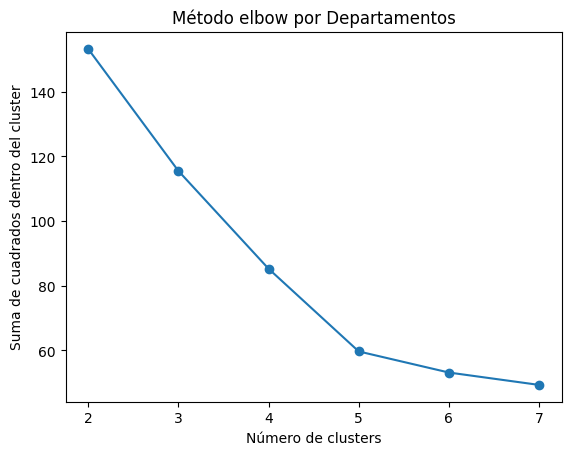

In [461]:
datos_para_clustering = data_all[
    ( data_all["Edadif"] >= 0 ) & ( data_all["Edadif"] <= 110 ) ].copy()

resumen_por_departamento = datos_para_clustering.groupby("Departamento").agg(
   
    edad_promedio= ("Edadif", "mean"),
    total_defunciones= ( "Edadif", "count" ) ,
    porcentaje_rural= ( "Area_desc", lambda x: (x == "Rural").mean() ),
    porcentaje_hombres= ( "Sexo_desc", lambda x:  (x == "Hombre").mean())
)

causas_tops = datos_para_clustering[ "caudef.descrip" ].value_counts().head(5).index

perfil_causas_depa= (
    datos_para_clustering[datos_para_clustering[ "caudef.descrip" ].isin(causas_tops)]
    .groupby([ "Departamento" , "caudef.descrip"])
    .size()
    .unstack(fill_value= 0)
)

causas_depa = perfil_causas_depa.div(perfil_causas_depa.sum(axis=1) , axis=0 )

datos_para_clustering = resumen_por_departamento.join(causas_depa).fillna(0)



datosEscalados = StandardScaler()
datosEscalados = datosEscalados.fit_transform( datos_para_clustering)

sumaDeCuadrados = []

for k in range(2,8):
    kmeans = KMeans(n_clusters=k , random_state =123)
    kmeans.fit(datosEscalados)
    sumaDeCuadrados.append( kmeans.inertia_)

plt.plot(range(2,8), sumaDeCuadrados, marker= "o" )
plt.title("Método elbow por Departamentos")
plt.xlabel("Número de clusters")
plt.ylabel("Suma de cuadrados dentro del cluster")
plt.show()


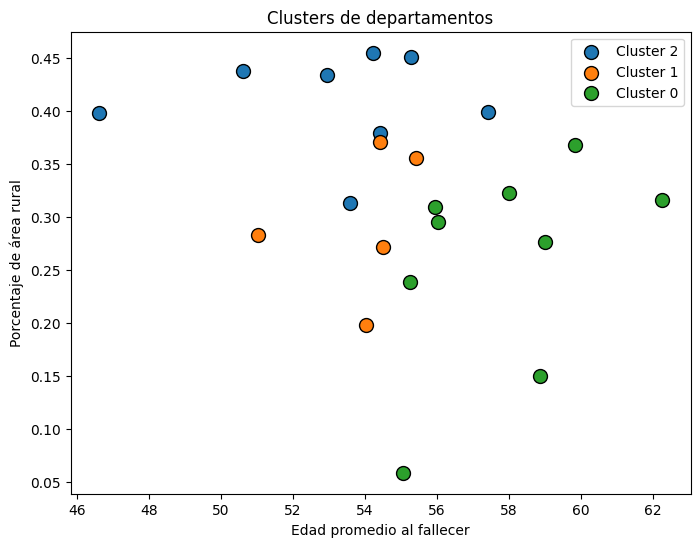

In [462]:
kmeans = KMeans(n_clusters=3, random_state=123)
datos_para_clustering["cluster"] = kmeans.fit_predict(datosEscalados)

datos_para_clustering["cluster"] = kmeans.fit_predict(datosEscalados)

plt.figure(figsize=(8,6))

for c in datos_para_clustering["cluster"].unique():
    subset = datos_para_clustering[datos_para_clustering["cluster"] == c]
    plt.scatter(
        subset["edad_promedio"],
        subset["porcentaje_rural"],
        label=f"Cluster {c}",
        s=100,
        edgecolor="black"
    )

plt.xlabel("Edad promedio al fallecer")
plt.ylabel("Porcentaje de área rural")
plt.legend()
plt.title("Clusters de departamentos")
plt.show()


### edad y porcentaje rural 

Para k = 2, silhouette = 0.308


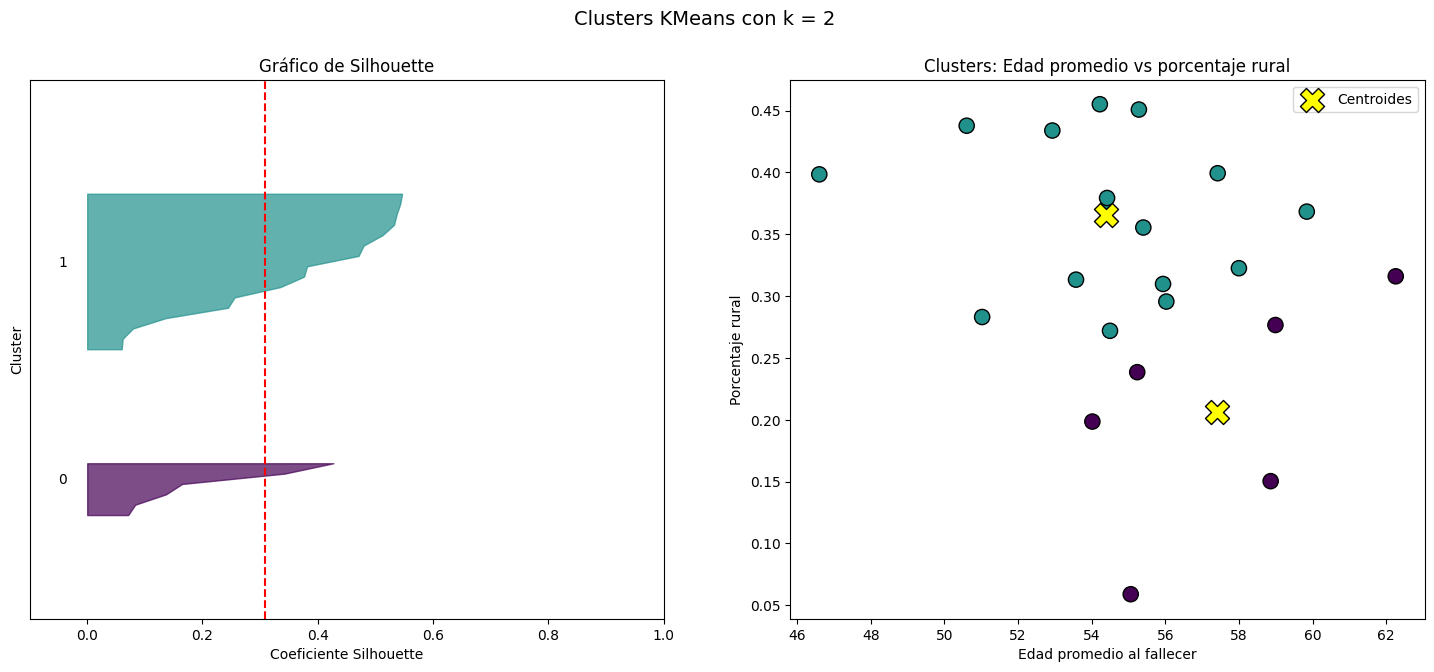

Para k = 3, silhouette = 0.309


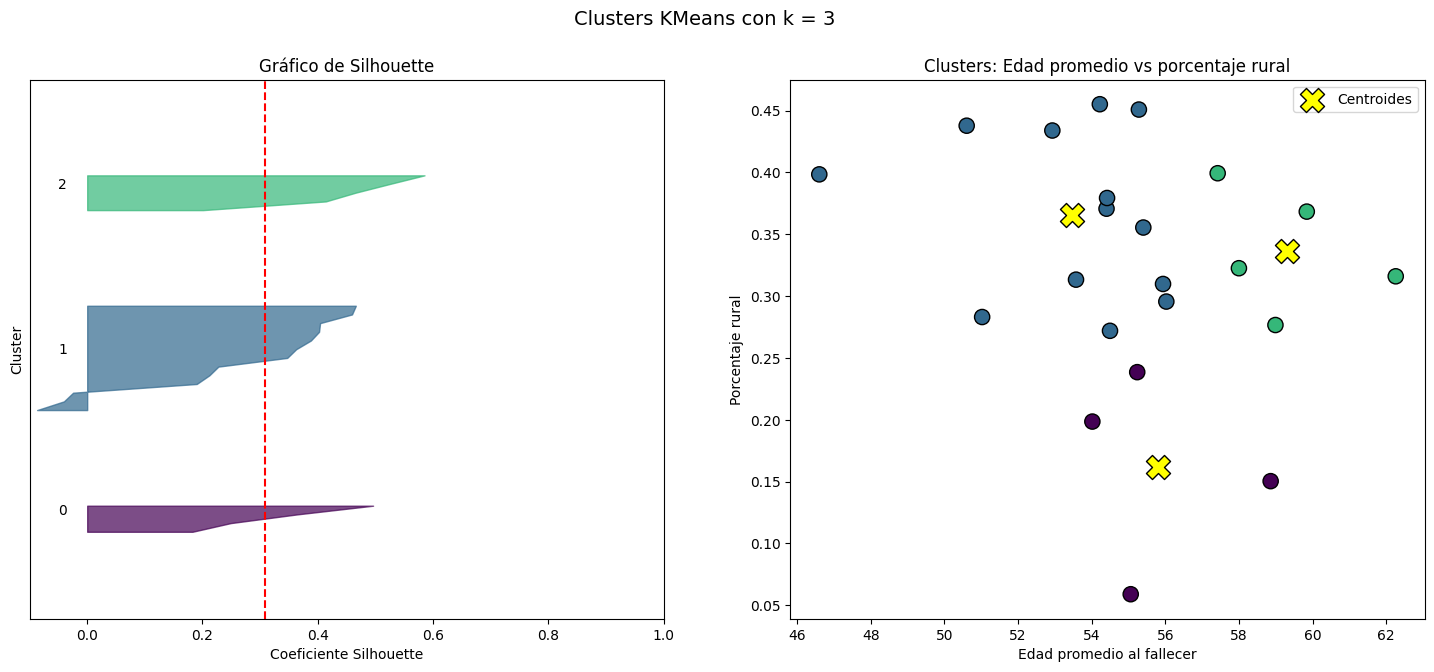

Para k = 4, silhouette = 0.319


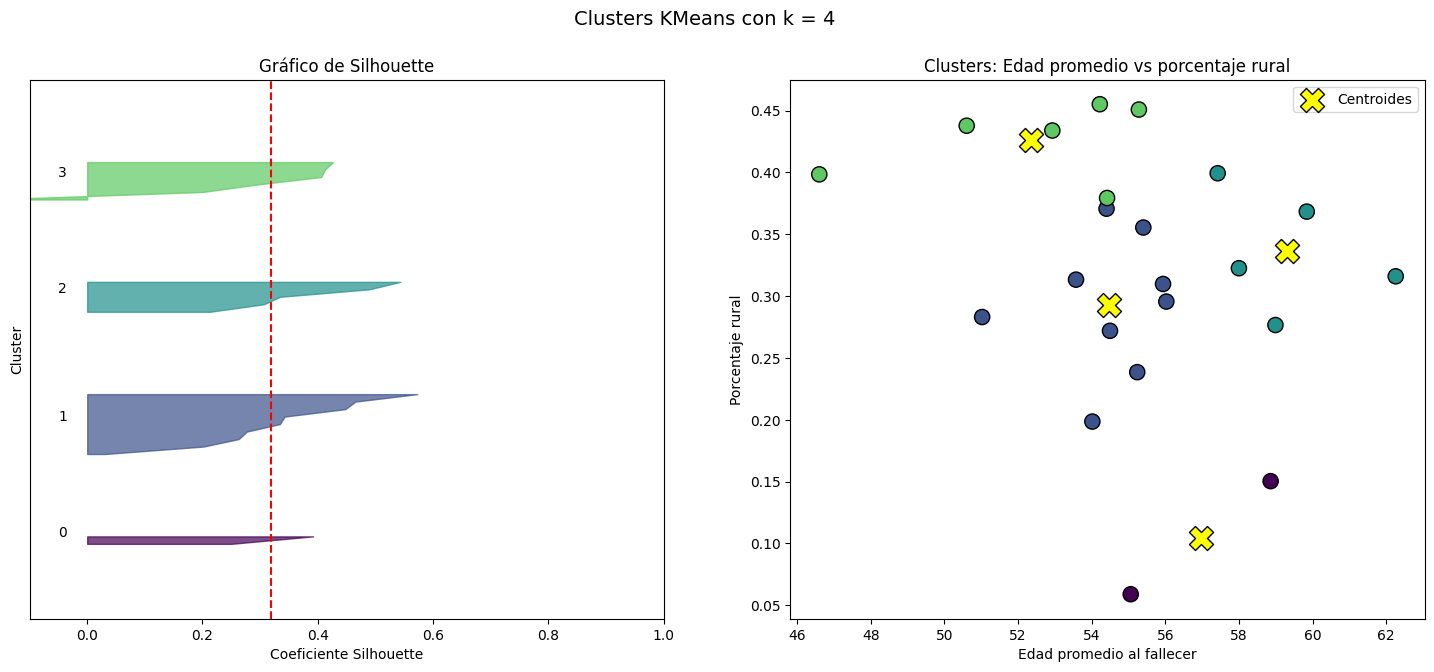

In [475]:
datosClustering = resumen_por_departamento[
    ["edad_promedio", "porcentaje_rural"]
]

escalar = StandardScaler() 
datosEscalados = escalar.fit_transform(datosClustering)

listaClusters = [2, 3, 4]

for numeroClusters in listaClusters:
    figura, (graficaSilhouette, graficaClusters) = plt.subplots(1, 2)
    figura.set_size_inches(18, 7)

    graficaSilhouette.set_xlim([ -0.1, 1] )
    graficaSilhouette.set_ylim([0 , len(datosEscalados)+ (numeroClusters + 1) * 10 ] )

    modeloKmeans = KMeans(n_clusters=numeroClusters, random_state=123 )
    etiquetasCluster = modeloKmeans.fit_predict(datosEscalados)

    promedioSilhouette = silhouette_score(datosEscalados, etiquetasCluster)
    print(f"Para k = {numeroClusters}, silhouette = {promedioSilhouette:.3f}")

    valoresSilhouette = silhouette_samples(datosEscalados, etiquetasCluster)

    limiteInferior = 10

    for clusterActual in range(numeroClusters ):

        valoresCluster= valoresSilhouette[etiquetasCluster  == clusterActual]
        valoresCluster.sort()

        tamañoCluster= valoresCluster.shape[0]
        limiteSuperior= limiteInferior +  tamañoCluster

        color= cm.viridis(float(clusterActual) /  numeroClusters)

        graficaSilhouette.fill_betweenx(
            np.arange(limiteInferior, limiteSuperior),
            0,
            valoresCluster,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        graficaSilhouette.text(-0.05, limiteInferior + 0.5 * tamañoCluster, str(clusterActual))
        limiteInferior = limiteSuperior + 10

    graficaSilhouette.set_title("Gráfico de Silhouette")
    graficaSilhouette.set_xlabel("Coeficiente Silhouette")
    graficaSilhouette.set_ylabel("Cluster")
    graficaSilhouette.axvline(x=promedioSilhouette, color="red", linestyle="--")
    graficaSilhouette.set_yticks([])

    colores = cm.viridis(etiquetasCluster.astype(float) / numeroClusters)

    graficaClusters.scatter(
        datosClustering["edad_promedio"],
        datosClustering["porcentaje_rural"],
        c=colores,
        s=120,
        edgecolor="black"
    )

    

    centroides = modeloKmeans.cluster_centers_
    centroidesOriginales = escalar.inverse_transform(centroides)

    graficaClusters.scatter(
        centroidesOriginales[:, 0],
        centroidesOriginales[:, 1],
        marker="X",
        c="yellow",
        s=300,
        edgecolor="black",
        label="Centroides"
    )

    graficaClusters.set_title("Clusters: Edad promedio vs porcentaje rural")
    graficaClusters.set_xlabel("Edad promedio al fallecer")
    graficaClusters.set_ylabel("Porcentaje rural")
    graficaClusters.legend()

    plt.suptitle(f"Clusters KMeans con k = {numeroClusters}", fontsize=14)
    plt.show()

